# Lab 2.1 (การบ้าน) · Data Profiling ข้อมูลลูกค้า `customers.csv`

ต่อยอดจากใบงาน Lab 2.1: ทำ **data profiling** หรือค้นหาความผิดปกติของ `customers.csv` (สมาชิกร้านบ้านบรู 3,000 คน) ก่อนนำไปแสดงผลบน Dashboard

| ขั้น | ทำอะไร |
|---|---|
| 0 | เตรียมเครื่องมือและโหลดข้อมูล |
| 1 | ดูข้อมูลครั้งแรก |
| 2 | Profiling: หาความผิดปกติ **แต่ยังไม่แก้** |
| 3 | สรุปสิ่งที่พบและตัดสินใจ |
| 4 | ทำความสะอาด (พร้อม log) |
| 5 | Verify และ Export `customers_clean.csv` |
| 6 | ดูภาพรวมลูกค้าหลังทำความสะอาด |

**ใช้งานบน Google Colab:** รันเซลล์จากบนลงล่าง เมื่อถึงขั้นโหลดไฟล์ Colab จะมีปุ่มให้อัปโหลด `customers.csv` (และ `sales.csv` ไม่บังคับ ใช้ตรวจความสอดคล้องกับยอดขาย)

## ขั้นที่ 0 · เตรียมเครื่องมือ
ฟังก์ชัน `get_file()` หาไฟล์ในโฟลเดอร์ปัจจุบันก่อน ถ้าไม่เจอและรันบน Colab จะเปิดให้อัปโหลด

In [1]:
import os, re
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

def get_file(name, required=True):
    """หาไฟล์ในโฟลเดอร์ปัจจุบัน/../public/public ถ้าไม่เจอและอยู่บน Colab ให้อัปโหลด"""
    for folder in [".", "../public", "public"]:
        path = os.path.join(folder, name)
        if os.path.exists(path):
            return path
    try:
        from google.colab import files
        print(f"กรุณาอัปโหลด {name}" + ("" if required else " (ไม่บังคับ กด Cancel เพื่อข้าม)"))
        up = files.upload()
        if name in up:
            return name
    except ImportError:
        pass
    if required:
        raise FileNotFoundError(f"ไม่พบไฟล์ {name}")
    return None

def load_csv(path):
    # อ่านทุกคอลัมน์เป็นข้อความ เพื่อไม่ให้ pandas เดาชนิดแล้วซ่อนปัญหา (ค่าว่างต้องเป็น "")
    return pd.read_csv(path, dtype=str, keep_default_na=False, encoding="utf-8-sig")

print("พร้อมใช้งาน")

พร้อมใช้งาน


## ขั้นที่ 1 · ดูข้อมูลครั้งแรก

In [2]:
df = load_csv(get_file("customers.csv"))
print(f"{len(df):,} แถว × {df.shape[1]} คอลัมน์")
df.head(8)

3,000 แถว × 7 คอลัมน์


,customer_id,nickname,gender,age_group,home_branch_id,joined_date,phone
0,C00001,กมล,หญิง,18-24,B02,2026-03-03,082-xxx-6693
1,C00002,กิตติ,ชาย,25-34,B04,2026-01-18,084-xxx-3734
2,C00003,ปิยะ,หญิง,18-24,B04,2025-05-04,089-xxx-9286
3,C00004,ปิยะ,หญิง,18-24,B05,2026-05-05,083-xxx-7314
4,C00005,รัตนา,หญิง,25-34,B04,2026-07-10,083-xxx-5701
5,C00006,กมล,ชาย,18-24,B04,2026-08-16,086-xxx-1895
6,C00007,วรรณ,ชาย,45-54,B03,2026-07-17,087-xxx-3147
7,C00008,ภัทร,หญิง,25-34,B01,2026-04-07,087-xxx-9877


In [3]:
df.describe(include="all").T

,count,unique,top,freq
customer_id,3000,3000,C00001,1
nickname,3000,24,อัญชลี,148
gender,3000,3,หญิง,1652
age_group,3000,6,25-34,993
home_branch_id,3000,5,B01,776
joined_date,3000,530,2025-10-20,13
phone,3000,2950,083-xxx-5083,3


## ขั้นที่ 2 · Profiling: หาความผิดปกติ (ยังไม่แก้)

**Prompt ที่ใช้กับ AI**
```
ช่วยทำ data profiling หรือค้นหาความผิดปกติของข้อมูล customers.csv แล้วสร้างเป็นไฟล์สำหรับทำงานบน google colab
(อ่านทุกคอลัมน์เป็น str ค่าว่างเป็น "") ตรวจ: ค่าว่าง, ค่าซ้ำ, รูปแบบของแต่ละคอลัมน์, ค่านอกชุดที่อนุญาต,
ช่วงวันที่, ความสัมพันธ์กับสาขา และความสอดคล้องกับ sales.csv รายงานอย่างเดียว อย่าแก้ข้อมูล
```
เก็บผลทุกข้อไว้ใน `findings` เพื่อสรุปเป็นตารางตอนท้ายขั้นนี้

### 2.1 ค่าว่างและค่าไม่ซ้ำของแต่ละคอลัมน์

In [4]:
findings = []   # (หัวข้อ, จำนวนที่พบ, หมายเหตุ)

profile = pd.DataFrame({
    "ค่าว่าง": (df == "").sum(),
    "ค่าที่มีช่องว่างหัวท้าย": df.apply(lambda s: (s != s.str.strip()).sum()),
    "ค่าไม่ซ้ำ": df.nunique(),
})
display(profile)
findings.append(("ค่าว่างทุกคอลัมน์", int(profile["ค่าว่าง"].sum()), "ไม่มีค่าว่าง" if profile["ค่าว่าง"].sum() == 0 else "มีค่าว่าง"))

,ค่าว่าง,ค่าที่มีช่องว่างหัวท้าย,ค่าไม่ซ้ำ
customer_id,0,0,3000
nickname,0,0,24
gender,0,0,3
age_group,0,0,6
home_branch_id,0,0,5
joined_date,0,0,530
phone,0,0,2950


### 2.2 ความซ้ำ

In [5]:
n_dup_rows = int(df.duplicated().sum())
n_dup_id = int(df["customer_id"].duplicated().sum())
print(f"แถวที่ซ้ำกันทุกคอลัมน์: {n_dup_rows}")
print(f"customer_id ซ้ำ: {n_dup_id}")

# เบอร์โทรซ้ำกันระหว่างลูกค้าคนละ id
dup_phone = df[df["phone"].duplicated(keep=False)].sort_values("phone")
n_phone_groups = dup_phone["phone"].nunique()
print(f"เบอร์โทรที่ใช้ซ้ำกันหลาย id: {n_phone_groups} เบอร์ (รวม {len(dup_phone)} แถว)")
display(dup_phone.head(8))
findings.append(("แถวซ้ำทุกคอลัมน์", n_dup_rows, ""))
findings.append(("customer_id ซ้ำ", n_dup_id, ""))
findings.append(("เบอร์โทรซ้ำข้าม customer_id", len(dup_phone), f"{n_phone_groups} เบอร์ ต้องตัดสินใจว่าเป็นคนเดียวกันหรือไม่"))

แถวที่ซ้ำกันทุกคอลัมน์: 0
customer_id ซ้ำ: 0
เบอร์โทรที่ใช้ซ้ำกันหลาย id: 49 เบอร์ (รวม 99 แถว)


,customer_id,nickname,gender,age_group,home_branch_id,joined_date,phone
2206,C02207,ทิพย์,ชาย,35-44,B02,2025-04-14,081-xxx-4308
2247,C02248,อัญชลี,ชาย,35-44,B02,2026-03-15,081-xxx-4308
2178,C02179,อัญชลี,หญิง,25-34,B01,2025-06-24,081-xxx-5843
2842,C02843,ธีร,หญิง,25-34,B05,2026-05-20,081-xxx-5843
1906,C01907,ศิริ,หญิง,25-34,B03,2026-03-31,081-xxx-6451
883,C00884,ภัทร,ชาย,45-54,B01,2025-09-07,081-xxx-6451
1634,C01635,ธีร,หญิง,18-24,B01,2026-04-28,081-xxx-8023
132,C00133,มานพ,ชาย,35-44,B02,2025-06-08,081-xxx-8023


### 2.3 รูปแบบของแต่ละคอลัมน์

In [6]:
bad_id    = ~df["customer_id"].str.match(r"^C\d{5}$")
bad_phone = ~df["phone"].str.match(r"^0\d{2}-xxx-\d{4}$")
print("customer_id ผิดรูปแบบ (C + เลข 5 หลัก):", int(bad_id.sum()))
print("phone ผิดรูปแบบ (0xx-xxx-nnnn):", int(bad_phone.sum()))

dates = pd.to_datetime(df["joined_date"].str[:10], errors="coerce", format="%Y-%m-%d")
bad_date = dates.isna()
print("joined_date แปลงไม่ได้:", int(bad_date.sum()))
print("ช่วงวันที่สมัคร:", dates.min().date(), "ถึง", dates.max().date())
print("joined_date ที่มีเวลาติดมา (ยาวกว่า 10 ตัวอักษร):", int((df["joined_date"].str.len() > 10).sum()))

findings.append(("customer_id ผิดรูปแบบ", int(bad_id.sum()), ""))
findings.append(("phone ผิดรูปแบบ", int(bad_phone.sum()), ""))
findings.append(("joined_date แปลงไม่ได้", int(bad_date.sum()), ""))

customer_id ผิดรูปแบบ (C + เลข 5 หลัก): 0
phone ผิดรูปแบบ (0xx-xxx-nnnn): 0
joined_date แปลงไม่ได้: 0
ช่วงวันที่สมัคร: 2025-04-01 ถึง 2026-09-14
joined_date ที่มีเวลาติดมา (ยาวกว่า 10 ตัวอักษร): 0


### 2.4 ค่านอกชุดที่อนุญาต (categorical)

In [7]:
ALLOWED = {
    "gender": ["ชาย", "หญิง", "ไม่ระบุ"],
    "age_group": ["ต่ำกว่า 18", "18-24", "25-34", "35-44", "45-54", "55+"],
    "home_branch_id": ["B01", "B02", "B03", "B04", "B05"],
}
for col, ok in ALLOWED.items():
    vc = df[col].value_counts()
    outside = vc[~vc.index.isin(ok)]
    print(f"--- {col}: นอกชุดที่อนุญาต {int(outside.sum())} แถว")
    print(vc.to_string())
    findings.append((f"{col} นอกชุดที่อนุญาต", int(outside.sum()), ""))

n_unknown_gender = int((df["gender"] == "ไม่ระบุ").sum())
n_minor = int((df["age_group"] == "ต่ำกว่า 18").sum())
print(f"\nเพศ 'ไม่ระบุ': {n_unknown_gender} แถว ({n_unknown_gender/len(df):.1%})")
print(f"อายุ 'ต่ำกว่า 18': {n_minor} แถว ({n_minor/len(df):.1%})")
findings.append(("เพศ 'ไม่ระบุ'", n_unknown_gender, "ไม่ใช่ข้อผิดพลาด แต่ต้องรู้ตอนวิเคราะห์ตามเพศ"))
findings.append(("สมาชิกอายุต่ำกว่า 18", n_minor, "ไม่ใช่ข้อผิดพลาด แต่เป็นกลุ่มที่ต้องระวังเรื่องข้อมูลส่วนบุคคล/การตลาด"))

--- gender: นอกชุดที่อนุญาต 0 แถว
gender
หญิง       1652
ชาย        1232
ไม่ระบุ     116
--- age_group: นอกชุดที่อนุญาต 0 แถว
age_group
25-34         993
18-24         775
35-44         577
45-54         346
55+           196
ต่ำกว่า 18    113
--- home_branch_id: นอกชุดที่อนุญาต 0 แถว
home_branch_id
B01    776
B05    693
B02    643
B04    483
B03    405

เพศ 'ไม่ระบุ': 116 แถว (3.9%)
อายุ 'ต่ำกว่า 18': 113 แถว (3.8%)


### 2.5 ความสัมพันธ์กับสาขา (วันสมัครต้องไม่ก่อนวันที่สาขาเปิด)

In [8]:
# วันเปิดสาขาจาก branches.csv ของ Lab 1
OPENED = {"B01": "2023-06-01", "B02": "2023-09-15", "B03": "2025-11-01", "B04": "2024-03-01", "B05": "2024-06-01"}
opened = df["home_branch_id"].map(OPENED)
before_open = dates < pd.to_datetime(opened)
print("สมัครก่อนสาขาเปิด:", int(before_open.sum()))
print()
print("สาขาอารีย์ (B03) เปิด 1 พ.ย. 2025 จำนวนสมาชิกที่สมัครหลังวันเปิด (True) / ก่อนวันเปิด (False):")
print((dates[df["home_branch_id"] == "B03"] >= "2025-11-01").value_counts().to_string())
findings.append(("สมัครก่อนวันที่สาขาเปิด", int(before_open.sum()), ""))

สมัครก่อนสาขาเปิด: 0

สาขาอารีย์ (B03) เปิด 1 พ.ย. 2025 จำนวนสมาชิกที่สมัครหลังวันเปิด (True) / ก่อนวันเปิด (False):
joined_date
True    405


### 2.6 ความสอดคล้องกับ `sales.csv` (ไม่บังคับ)

In [9]:
sales_path = get_file("sales.csv", required=False)
has_sales = sales_path is not None
if has_sales:
    sales = load_csv(sales_path)
    sales["qty"] = pd.to_numeric(sales["qty"]); sales["unit_price"] = pd.to_numeric(sales["unit_price"])
    buyers = set(sales.loc[sales["customer_id"] != "", "customer_id"])
    members = set(df["customer_id"])
    n_unknown_buyer = len(buyers - members)
    n_no_purchase = len(members - buyers)
    print(f"customer_id ในยอดขายที่ไม่มีในตารางลูกค้า: {n_unknown_buyer}")
    print(f"สมาชิกที่ไม่เคยซื้อเลย: {n_no_purchase} ({n_no_purchase/len(members):.1%})")

    first = sales[sales["customer_id"] != ""].assign(d=lambda x: pd.to_datetime(x["datetime"].str[:10])).groupby("customer_id")["d"].min()
    joined = pd.Series(dates.values, index=df["customer_id"])
    n_before_join = int((first < joined.reindex(first.index)).sum())
    print(f"ซื้อครั้งแรก ก่อนวันที่สมัครสมาชิก: {n_before_join}")
    findings.append(("customer_id ในยอดขายที่ไม่มีในตารางลูกค้า", n_unknown_buyer, ""))
    findings.append(("สมาชิกที่ไม่เคยซื้อเลย", n_no_purchase, f"{n_no_purchase/len(members):.1%} ของสมาชิก"))
    findings.append(("ซื้อครั้งแรกก่อนวันสมัคร", n_before_join, ""))
else:
    print("ข้ามขั้นนี้ (ไม่ได้อัปโหลด sales.csv)")

customer_id ในยอดขายที่ไม่มีในตารางลูกค้า: 0
สมาชิกที่ไม่เคยซื้อเลย: 493 (16.4%)


ซื้อครั้งแรก ก่อนวันที่สมัครสมาชิก: 0


### 2.7 การกระจายของวันสมัคร (หาช่วงที่ผิดปกติ)

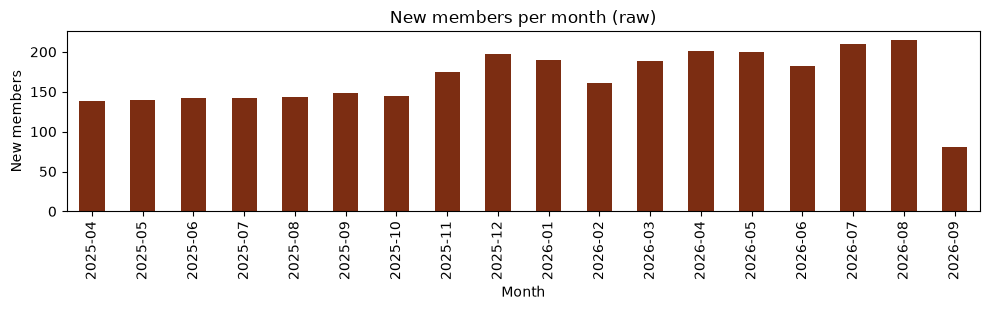

เดือนล่าสุดมีข้อมูลบางส่วน: 2026-09 = 81 คน (ข้อมูลสิ้นสุด 20 ก.ย. 2026)


In [10]:
monthly = dates.dt.to_period("M").value_counts().sort_index()
ax = monthly.plot.bar(color="#7c2d12", figsize=(10, 3.2))
ax.set_xlabel("Month"); ax.set_ylabel("New members"); ax.set_title("New members per month (raw)")
plt.tight_layout(); plt.show()
print("เดือนล่าสุดมีข้อมูลบางส่วน:", monthly.index[-1], "=", int(monthly.iloc[-1]), "คน (ข้อมูลสิ้นสุด 20 ก.ย. 2026)")

### 2.8 สรุปสิ่งที่พบ

In [11]:
summary = pd.DataFrame(findings, columns=["หัวข้อที่ตรวจ", "จำนวนที่พบ", "หมายเหตุ"])
summary

,หัวข้อที่ตรวจ,จำนวนที่พบ,หมายเหตุ
0,ค่าว่างทุกคอลัมน์,0,ไม่มีค่าว่าง
1,แถวซ้ำทุกคอลัมน์,0,
2,customer_id ซ้ำ,0,
3,เบอร์โทรซ้ำข้าม customer_id,99,49 เบอร์ ต้องตัดสินใจว่าเป็นคนเดียวกันหรือไม่
4,customer_id ผิดรูปแบบ,0,
5,phone ผิดรูปแบบ,0,
6,joined_date แปลงไม่ได้,0,
7,gender นอกชุดที่อนุญาต,0,
8,age_group นอกชุดที่อนุญาต,0,
9,home_branch_id นอกชุดที่อนุญาต,0,


## ขั้นที่ 3 · ตัดสินใจก่อนลงมือ

AI ช่วยหาปัญหาได้ แต่ **คนที่รู้ธุรกิจต้องเป็นคนตัดสินใจ** ผลการตรวจสรุปว่าข้อมูลลูกค้าชุดนี้ **สะอาดในระดับโครงสร้าง** (ไม่มีค่าว่าง ไม่มีแถวซ้ำ รูปแบบถูกต้อง ค่าอยู่ในชุดที่อนุญาต) จุดที่ต้องตัดสินใจมีไม่กี่ข้อ

| ประเด็นที่พบ | ทางเลือก | ตัดสินใจ | เหตุผล |
|---|---|---|---|
| `joined_date` อาจมีเวลา `00:00:00` ติดมา (เมื่อมาจากไฟล์ Excel) | ตัดเวลา / เก็บ | **ตัดเหลือ `YYYY-MM-DD`** | ข้อมูลเป็นวันที่ ไม่ใช่เวลา และแสดงผลง่ายกว่า |
| เบอร์โทรซ้ำข้าม `customer_id` | ลบแถว / รวมลูกค้า / ทำธง | **ติดธง `phone_shared` ไม่ลบ** | เบอร์ถูกปิดบังบางส่วน (`xxx`) จึงยืนยันไม่ได้ว่าเป็นคนเดียวกัน และ id ต่างกันมีประวัติซื้อของตัวเอง การลบจะทำให้ยอดขายของสมาชิกหาย |
| เพศ `ไม่ระบุ` | เก็บ / ลบ / เติมค่า | **เก็บไว้เป็นหมวดหนึ่ง** | เป็นคำตอบจริงของลูกค้า ห้ามเดา |
| อายุ `ต่ำกว่า 18` | เก็บ / ลบ | **เก็บและแสดงเป็นหมวดแยก** | ไม่ใช่ข้อผิดพลาด แต่ควรรู้ว่ามีกลุ่มนี้ตอนทำการตลาด |
| สมาชิกที่ไม่เคยซื้อเลย | ลบ / เก็บ | **เก็บ** | เป็นสมาชิกจริง ใช้วิเคราะห์ว่าสมัครแล้วไม่ใช้งานได้ |
| ชื่อเล่นซ้ำกันมาก (มีแค่ 24 ชื่อ) | - | **ไม่ถือเป็นปัญหา** | ชื่อเล่นไม่ใช่คีย์ ใช้ `customer_id` แยกคน |

> หลักการ: ถ้าไม่มั่นใจว่าเป็นข้อผิดพลาด ให้ **ติดธงแทนการลบ** เพราะลบแล้วย้อนกลับไม่ได้

## ขั้นที่ 4 · ทำความสะอาด

**Prompt**
```
เขียนโค้ด pandas ทำความสะอาด df (อ่านมาเป็น str ทุกคอลัมน์) ทำงานบน clean = df.copy() ห้ามแก้ df
แยกแต่ละขั้นเป็นขั้นตอนชัดเจนและเก็บ log (ขั้นตอน, จำนวนแถวที่กระทบ, การตัดสินใจ)
ตัดช่องว่างทุกคอลัมน์, ตัดเวลาออกจาก joined_date, ติดธง phone_shared สำหรับเบอร์ซ้ำ,
ไม่ลบแถวใด ๆ, แสดง log เป็นตารางและจำนวนแถวก่อน/หลัง
```

In [12]:
clean = df.copy()
log = []
def step(name, affected, decision):
    log.append({"ขั้นตอน": name, "จำนวนแถวที่กระทบ": int(affected), "การตัดสินใจ": decision})

# 1) ตัดช่องว่างหัวท้ายทุกคอลัมน์
before = clean.copy()
clean = clean.apply(lambda s: s.str.strip())
step("ตัดช่องว่างหัวท้าย", (before != clean).any(axis=1).sum(), "strip ทุกคอลัมน์")

# 2) joined_date -> YYYY-MM-DD
before = clean["joined_date"].copy()
clean["joined_date"] = pd.to_datetime(clean["joined_date"].str[:10], format="%Y-%m-%d").dt.strftime("%Y-%m-%d")
step("joined_date เป็น YYYY-MM-DD", (before != clean["joined_date"]).sum(), "ตัดเวลาที่ติดมาออก")

# 3) ติดธงเบอร์โทรซ้ำ (ไม่ลบแถว)
clean["phone_shared"] = clean["phone"].duplicated(keep=False)
step("ติดธง phone_shared", clean["phone_shared"].sum(), "เบอร์ซ้ำข้าม id ติดธง ไม่ลบ")

# 4) แถวซ้ำ (ไม่พบ แต่ลบให้แน่ใจ และบันทึกจำนวน)
n0 = len(clean)
clean = clean.drop_duplicates()
step("ลบแถวซ้ำทุกคอลัมน์", n0 - len(clean), "ไม่พบแถวซ้ำ" if n0 == len(clean) else "ลบแถวซ้ำ")

clean = clean.reset_index(drop=True)
cleaning_log = pd.DataFrame(log)
print(f"ก่อน {len(df):,} แถว -> หลัง {len(clean):,} แถว")
cleaning_log

ก่อน 3,000 แถว -> หลัง 3,000 แถว


,ขั้นตอน,จำนวนแถวที่กระทบ,การตัดสินใจ
0,ตัดช่องว่างหัวท้าย,0,strip ทุกคอลัมน์
1,joined_date เป็น YYYY-MM-DD,0,ตัดเวลาที่ติดมาออก
2,ติดธง phone_shared,99,เบอร์ซ้ำข้าม id ติดธง ไม่ลบ
3,ลบแถวซ้ำทุกคอลัมน์,0,ไม่พบแถวซ้ำ


## ขั้นที่ 5 · Verify และ Export
ตรวจว่าข้อมูลที่ทำความสะอาดแล้วพร้อมใช้ใน Dashboard ทุกข้อต้องเป็น ✅ ก่อน export

In [13]:
def validate(d):
    checks = {
        "ไม่มีแถวซ้ำ": d.duplicated().sum() == 0,
        "customer_id ไม่ซ้ำ": d["customer_id"].is_unique,
        "customer_id รูปแบบถูกต้อง": d["customer_id"].str.match(r"^C\d{5}$").all(),
        "ไม่มีค่าว่างในคอลัมน์หลัก": (d[["customer_id", "gender", "age_group", "home_branch_id", "joined_date"]] == "").sum().sum() == 0,
        "gender อยู่ในชุดที่อนุญาต": d["gender"].isin(ALLOWED["gender"]).all(),
        "age_group อยู่ในชุดที่อนุญาต": d["age_group"].isin(ALLOWED["age_group"]).all(),
        "home_branch_id อยู่ในชุดที่อนุญาต": d["home_branch_id"].isin(ALLOWED["home_branch_id"]).all(),
        "joined_date เป็น YYYY-MM-DD ทุกแถว": d["joined_date"].str.match(r"^\d{4}-\d{2}-\d{2}$").all(),
        "ไม่มีใครสมัครก่อนสาขาเปิด": (pd.to_datetime(d["joined_date"]) >= pd.to_datetime(d["home_branch_id"].map(OPENED))).all(),
        "จำนวนแถวเท่าเดิม (3,000)": len(d) == 3000,
    }
    for name, ok in checks.items():
        print("✅" if ok else "❌", name)
    print("\nผ่านทั้งหมด" if all(checks.values()) else "\nมีข้อที่ไม่ผ่าน")

validate(clean)

✅ ไม่มีแถวซ้ำ
✅ customer_id ไม่ซ้ำ
✅ customer_id รูปแบบถูกต้อง
✅ ไม่มีค่าว่างในคอลัมน์หลัก
✅ gender อยู่ในชุดที่อนุญาต
✅ age_group อยู่ในชุดที่อนุญาต
✅ home_branch_id อยู่ในชุดที่อนุญาต
✅ joined_date เป็น YYYY-MM-DD ทุกแถว
✅ ไม่มีใครสมัครก่อนสาขาเปิด
✅ จำนวนแถวเท่าเดิม (3,000)

ผ่านทั้งหมด


In [14]:
clean.to_csv("customers_clean.csv", index=False, encoding="utf-8-sig")
cleaning_log.to_csv("customers_cleaning_log.csv", index=False, encoding="utf-8-sig")
print("บันทึก customers_clean.csv และ customers_cleaning_log.csv แล้ว")

try:
    from google.colab import files
    files.download("customers_clean.csv")
    files.download("customers_cleaning_log.csv")
except ImportError:
    pass

บันทึก customers_clean.csv และ customers_cleaning_log.csv แล้ว


## ขั้นที่ 6 · ภาพรวมลูกค้าหลังทำความสะอาด
(ใช้ป้ายภาษาอังกฤษ เพราะ matplotlib ใน Colab ไม่มีฟอนต์ไทย จะแสดงเป็นกล่องสี่เหลี่ยม) กราฟแบบเต็มภาษาไทยอยู่บนหน้าเว็บ Dashboard

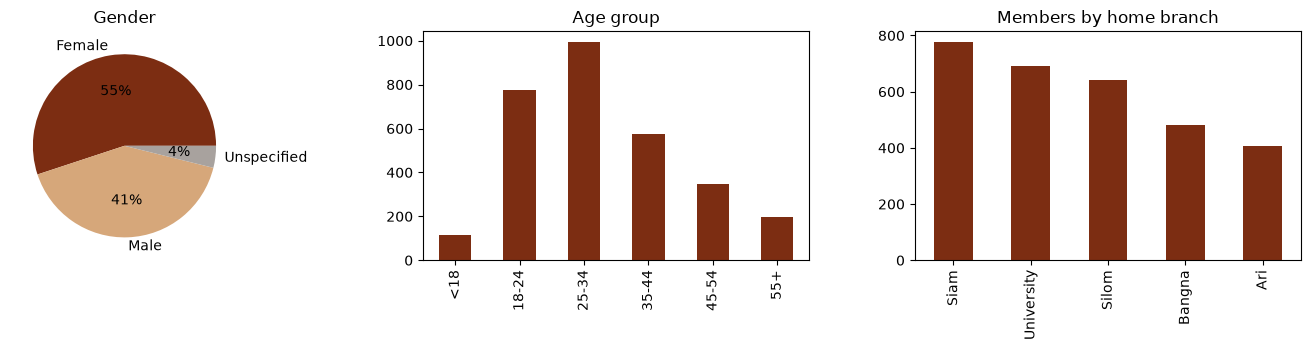

In [15]:
EN = {"ชาย": "Male", "หญิง": "Female", "ไม่ระบุ": "Unspecified", "ต่ำกว่า 18": "<18",
      "B01": "Siam", "B02": "Silom", "B03": "Ari", "B04": "Bangna", "B05": "University"}
fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
clean["gender"].map(EN).value_counts().plot.pie(ax=ax[0], autopct="%1.0f%%", colors=["#7c2d12", "#d6a77a", "#a8a29e"], ylabel="")
ax[0].set_title("Gender")
clean["age_group"].map(lambda v: EN.get(v, v)).value_counts().reindex(["<18", "18-24", "25-34", "35-44", "45-54", "55+"]).plot.bar(ax=ax[1], color="#7c2d12")
ax[1].set_title("Age group"); ax[1].set_xlabel("")
clean["home_branch_id"].map(EN).value_counts().plot.bar(ax=ax[2], color="#7c2d12")
ax[2].set_title("Members by home branch"); ax[2].set_xlabel("")
plt.tight_layout(); plt.show()

### สรุปผลการตรวจ
- ข้อมูลลูกค้า **สะอาดเชิงโครงสร้าง**: ไม่มีค่าว่าง ไม่มีแถวซ้ำ รูปแบบและค่าอยู่ในชุดที่อนุญาต และไม่มีใครสมัครก่อนสาขาเปิด
- **สิ่งที่ต้องรู้ก่อนวิเคราะห์:** มีเบอร์โทรซ้ำข้าม id, สมาชิกราว 16% ไม่เคยซื้อเลย, เพศ "ไม่ระบุ" ราว 4%, และเดือน ก.ย. 2026 มีข้อมูลบางส่วน
- **สิ่งที่ไม่ได้ทำ:** ไม่ลบแถวใดเลย เลือก "ติดธง" แทน เพราะยืนยันไม่ได้ว่าเป็นข้อผิดพลาดจริง

**คำถามชวนคิด:** ถ้าเบอร์โทรไม่ถูกปิดบัง (ไม่มี `xxx`) คุณจะใช้เบอร์ช่วยตัดสินว่าเป็นลูกค้าคนเดียวกันได้ไหม และควรทำอย่างไรกับยอดขายของ id ที่ซ้ำกัน